# ⚽ Step 4: Model Training & Evaluation

We train and compare **Random Forest**, **XGBoost**, and **SVM** under two experiments:

| Experiment | Target | Classes | Rows used |
|---|---|---|---|
| **1 — 3-class** | `target_3way` | Home Win / Draw / Away Win | ~5,900 |
| **2 — Binary** | `target_binary` | Home Win / Away Win | ~4,500 (draws dropped) |

**Time-based split (never random):**
- **Train** 2018/19–2021/22 → the models learn here
- **Validation** 2022/23 → we pick the best hyperparameters here
- **Test** 2023/24–2025/26 → the final score, untouched until the very end

The final models are refit on **Train + Validation** before the test evaluation, so no pre-test data is wasted. The model always learns from the past and is judged on the future.

## 1. Setup

In [1]:
import sys; sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import modeling as M
from features import feature_columns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

df = pd.read_csv("../data/processed/matches_features.csv", dtype={"Season": str})
feat_cols = feature_columns(df)

print("Total rows       :", len(df))
print("Feature columns  :", len(feat_cols))
print("Seasons          :", sorted(df["Season"].unique()))
print("Train seasons    :", M.TRAIN_SEASONS, "(learn)")
print("Val   seasons    :", M.VAL_SEASONS, "(tune hyperparameters)")
print("Test  seasons    :", M.TEST_SEASONS, "(final, untouched)")
print("Final fit on DEV :", M.DEV_SEASONS, "(train + validation)")

Total rows       : 6080
Feature columns  : 62
Seasons          : ['1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526']
Train seasons    : ['1819', '1920', '2021', '2122'] (learn)
Val   seasons    : ['2223'] (tune hyperparameters)
Test  seasons    : ['2324', '2425', '2526'] (final, untouched)
Final fit on DEV : ['1819', '1920', '2021', '2122', '2223'] (train + validation)


## 2. Preprocessing & Split

Steps (in order, all leakage-safe):
1. **Drop 161 season-opener rows** — form features are genuinely unavailable for the first game of each team's season.
2. **Time-based split** — training seasons vs test seasons. No random shuffle.
3. **Median imputation** — fitted on the training set, then applied to the test set. Handles h2h NaN (teams that never met), missing Pinnacle odds (oldest season), venue-form NaN (first home/away game), rest-days NaN (first appearance in dataset).
4. **StandardScaler** — fitted on training set, applied to test set. Mandatory for SVM; doesn't hurt RF/XGBoost.


In [2]:
X_train, X_test, y_train, y_test, train_df, test_df, pipe, le = M.preprocess(
    df, feat_cols, target_col="target_3way"   # split="dev_test" -> DEV (train+val) vs TEST
)

print("Label encoding   :", dict(zip(le.classes_, le.transform(le.classes_))))
print()
print(f"Dev (train+val) : {len(train_df):5d} matches  ({train_df['Season'].min()} -> {train_df['Season'].max()})")
print(f"Test            : {len(test_df):5d} matches  ({test_df['Season'].min()} -> {test_df['Season'].max()})")
print()
print("Dev (train+val) class distribution:")
for cls, n in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {le.classes_[cls]:6s}: {n:4d}  ({n/len(y_train):.1%})")
print("Test class distribution:")
for cls, n in zip(*np.unique(y_test, return_counts=True)):
    print(f"  {le.classes_[cls]:6s}: {n:4d}  ({n/len(y_test):.1%})")

Label encoding   : {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}

Dev (train+val) :  3699 matches  (1819 -> 2223)
Test            :  2220 matches  (2324 -> 2526)

Dev (train+val) class distribution:
  A     : 1126  (30.4%)
  D     :  922  (24.9%)
  H     : 1651  (44.6%)
Test class distribution:
  A     :  671  (30.2%)
  D     :  557  (25.1%)
  H     :  992  (44.7%)


---
## 3. Hyperparameter Tuning (Validation Set)

Before training the final models we **tune** each one. We try a handful of settings, train them on the **train** seasons, and keep whichever scores best on the **validation** season (2022/23). **The test set is never touched here** — that is the whole point of having a separate validation set.

The winners are saved to `best_params.json` and reused everywhere (including the betting notebook), so the *"we tuned the models"* claim is true **and** leakage-free.

In [3]:
best_params, tune_results = M.tune_models(df, feat_cols, target_col="target_3way")

print("Best settings chosen on the VALIDATION season (2022/23):")
for name, p in best_params.items():
    print(f"  {name:14s}: {p}")
print("\n(saved to data/processed/best_params.json — reused by every model below"
      "\n and by the betting-simulation notebook)\n")

# every candidate's validation accuracy, best per model on top
tune_results.sort_values(["Model", "val_accuracy"], ascending=[True, False])

Best settings chosen on the VALIDATION season (2022/23):
  Random Forest : {'max_depth': 6, 'min_samples_leaf': 1}
  XGBoost       : {'max_depth': 3, 'learning_rate': 0.03}
  SVM           : {'C': 0.5, 'gamma': 'scale'}

(saved to data/processed/best_params.json — reused by every model below
 and by the betting-simulation notebook)



,Model,max_depth,min_samples_leaf,val_accuracy,learning_rate,C,gamma
0,Random Forest,6.000,1.000,0.534,NaN,NaN,NaN
1,Random Forest,6.000,3.000,0.530,NaN,NaN,NaN
2,Random Forest,10.000,1.000,0.530,NaN,NaN,NaN
5,Random Forest,16.000,3.000,0.520,NaN,NaN,NaN
3,Random Forest,10.000,3.000,0.516,NaN,NaN,NaN
4,Random Forest,16.000,1.000,0.513,NaN,NaN,NaN
15,SVM,NaN,NaN,0.543,NaN,0.500,scale
17,SVM,NaN,NaN,0.536,NaN,1.000,scale
18,SVM,NaN,NaN,0.508,NaN,1.000,0.100
16,SVM,NaN,NaN,0.504,NaN,0.500,0.100


**Reading it:** each row is one candidate set of settings; `val_accuracy` is its score on the unseen **2022/23** season. We keep the **top row per model**. Football is genuinely hard to predict, so the gains are modest — but tuning reliably nudged every model up a little, and it was decided **without ever looking at the test set**. The chosen settings are now baked into every model the rest of the project trains.

## 4. Baseline — Bookmaker Favorite

The simplest possible predictor: always pick whichever outcome the bookmaker makes most likely.
**Any model that scores below this line is learning nothing useful.**

In [4]:
def bookmaker_baseline(sub_df):
    probs = sub_df[["mkt_b365_p_home", "mkt_b365_p_draw", "mkt_b365_p_away"]]
    fav_idx = probs.values.argmax(axis=1)
    fav_class = np.array(["H", "D", "A"])[fav_idx]
    acc = (fav_class == sub_df["target_3way"].values).mean()
    return acc

base_train = bookmaker_baseline(train_df)
base_test  = bookmaker_baseline(test_df)
print(f"Bookmaker-favorite accuracy — train : {base_train:.1%}")
print(f"Bookmaker-favorite accuracy — test  : {base_test:.1%}")
print()
print("This is the bar every model must beat.")

Bookmaker-favorite accuracy — train : 53.6%
Bookmaker-favorite accuracy — test  : 54.7%

This is the bar every model must beat.


---
## Experiment 1 — 3-class (Home / Draw / Away)

Train all three models on the full problem. This is the main experiment and the professor's core requirement.


In [5]:
print("Training 3-class models (tuned settings)...")
models_3 = M.train_all(X_train, y_train, model_defs=M.get_model_defs(best_params))
print("Done.")

Training 3-class models (tuned settings)...
  training Random Forest... 

done
  training XGBoost... 

done
  training SVM... 

done
Done.


In [6]:
results_3 = M.evaluate(models_3, X_test, y_test, le)
print("=== 3-class results (test set) ===\n")
for name, r in results_3.items():
    print(f"--- {name} ---")
    print(r["report"])

=== 3-class results (test set) ===

--- Random Forest ---
              precision    recall  f1-score   support

           A       0.51      0.53      0.52       671
           D       0.15      0.01      0.01       557
           H       0.56      0.84      0.67       992

    accuracy                           0.54      2220
   macro avg       0.41      0.46      0.40      2220
weighted avg       0.44      0.54      0.46      2220

--- XGBoost ---
              precision    recall  f1-score   support

           A       0.53      0.47      0.50       671
           D       0.23      0.06      0.10       557
           H       0.56      0.83      0.67       992

    accuracy                           0.53      2220
   macro avg       0.44      0.45      0.42      2220
weighted avg       0.47      0.53      0.47      2220

--- SVM ---
              precision    recall  f1-score   support

           A       0.52      0.53      0.53       671
           D       0.05      0.00      0.00

### Confusion Matrices

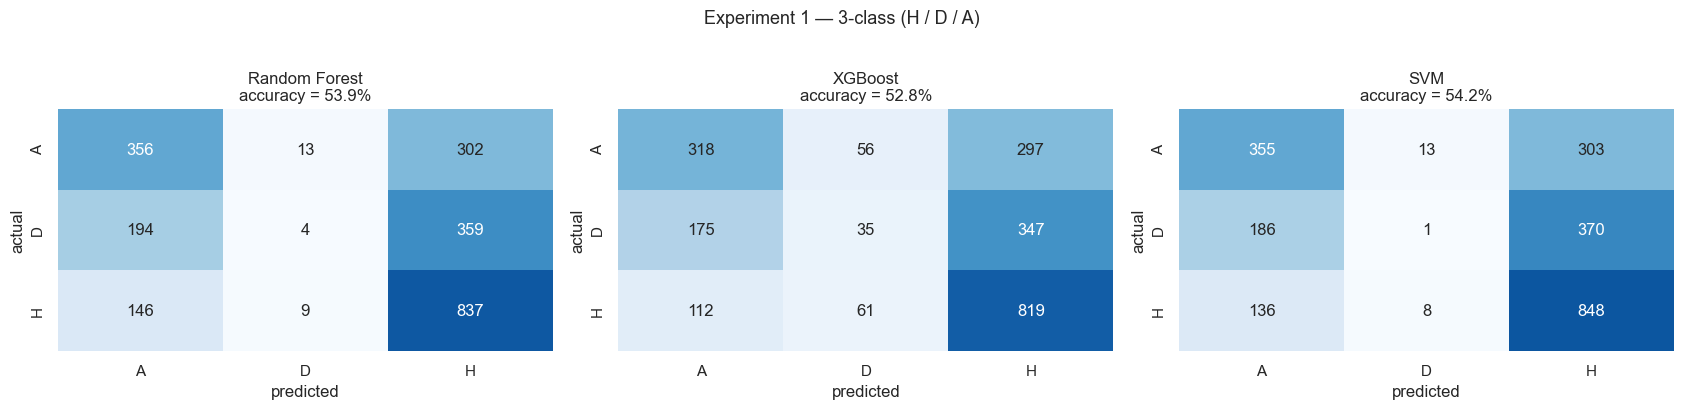

In [7]:
M.plot_cms(results_3, le, title="Experiment 1 — 3-class (H / D / A)")

**How to read:** rows = actual outcome, columns = predicted outcome.
The diagonal (top-left to bottom-right) = correct predictions.
Notice: the **Draw column is almost empty** in every model — models struggle to predict draws, which is exactly what the EDA warned us about.


### Metrics Comparison Table

In [8]:
tbl3 = M.metrics_table(results_3, le)
tbl3.insert(0, "Baseline", base_test)
tbl3

,Baseline,Accuracy,F1 (A),Recall (A),F1 (D),Recall (D),F1 (H),Recall (H),F1 weighted
Model,,,,,,,,,
Random Forest,0.547,0.539,0.521,0.531,0.014,0.007,0.672,0.844,0.461
XGBoost,0.547,0.528,0.498,0.474,0.099,0.063,0.667,0.826,0.474
SVM,0.547,0.542,0.527,0.529,0.003,0.002,0.675,0.855,0.462


### Per-league accuracy

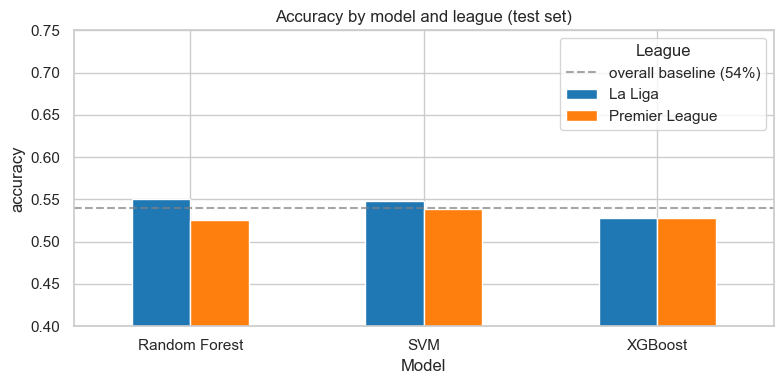


League         La Liga  Premier League
Model                                 
Random Forest    0.550           0.525
SVM              0.549           0.539
XGBoost          0.528           0.528


In [9]:
pvt3 = M.plot_per_league(models_3, test_df, feat_cols, pipe, le)
print()
print(pvt3.round(3))

**Key question:** does La Liga score higher or lower than EPL?
Recall the EDA finding: EPL had a *higher* bookmaker baseline (55.0% vs 53.1%), meaning **EPL is actually more predictable** than La Liga in this dataset. We expect the same pattern from the models.


---
## Experiment 2 — Binary (Home Win / Away Win, draws dropped)

We eliminate the draw class entirely, keeping only decisive matches (~74% of all games).
This answers: **how much of the difficulty comes from the draw class?**

This maps to a real betting market called *"Draw No Bet"* — where if the game ends in a draw, your stake is refunded. So this experiment has a direct real-world use case.

> ⚠️ Binary accuracy is NOT comparable to 3-class accuracy — different problem, different denominator. We use it only to measure the accuracy lift from removing draws.


In [10]:
X_tr2, X_te2, y_tr2, y_te2, tr2_df, te2_df, pipe2, le2 = M.preprocess(
    df, feat_cols, target_col="target_binary"
)
print("Label encoding (binary):", dict(zip(le2.classes_, le2.transform(le2.classes_))))
print(f"Train : {len(tr2_df)} matches (draws excluded)")
print(f"Test  : {len(te2_df)} matches (draws excluded)")
print(f"Draws dropped (test)  : {len(test_df) - len(te2_df)} ({(len(test_df)-len(te2_df))/len(test_df):.1%} of test set)")

Label encoding (binary): {'A': np.int64(0), 'H': np.int64(1)}
Train : 2777 matches (draws excluded)
Test  : 1663 matches (draws excluded)
Draws dropped (test)  : 557 (25.1% of test set)


In [11]:
print("Training binary models (tuned settings)...")
models_2 = M.train_all(X_tr2, y_tr2, model_defs=M.get_model_defs(best_params))
print("Done.")

Training binary models (tuned settings)...
  training Random Forest... 

done
  training XGBoost... 

done
  training SVM... 

done
Done.


In [12]:
results_2 = M.evaluate(models_2, X_te2, y_te2, le2)
print("=== Binary results (test set) ===\n")
for name, r in results_2.items():
    print(f"--- {name} ---")
    print(r["report"])

=== Binary results (test set) ===

--- Random Forest ---
              precision    recall  f1-score   support

           A       0.70      0.56      0.62       671
           H       0.74      0.84      0.79       992

    accuracy                           0.73      1663
   macro avg       0.72      0.70      0.71      1663
weighted avg       0.72      0.73      0.72      1663

--- XGBoost ---
              precision    recall  f1-score   support

           A       0.69      0.55      0.62       671
           H       0.73      0.83      0.78       992

    accuracy                           0.72      1663
   macro avg       0.71      0.69      0.70      1663
weighted avg       0.72      0.72      0.71      1663

--- SVM ---
              precision    recall  f1-score   support

           A       0.72      0.54      0.62       671
           H       0.73      0.86      0.79       992

    accuracy                           0.73      1663
   macro avg       0.73      0.70      0.70

### Confusion Matrices — Binary

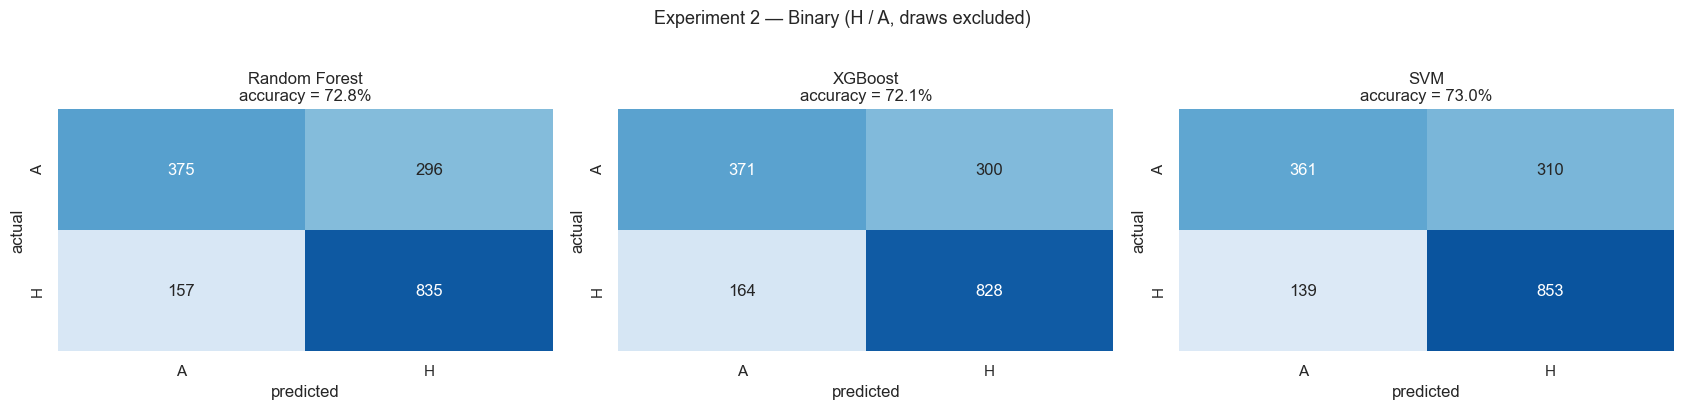

In [13]:
M.plot_cms(results_2, le2, title="Experiment 2 — Binary (H / A, draws excluded)")

---
## 5. Cross-Experiment Comparison

How much does accuracy jump when we drop draws?

In [14]:
comparison = pd.DataFrame({
    "3-class Accuracy": {n: r["accuracy"] for n, r in results_3.items()},
    "Binary Accuracy":  {n: r["accuracy"] for n, r in results_2.items()},
})
comparison["Accuracy lift"] = comparison["Binary Accuracy"] - comparison["3-class Accuracy"]
comparison.loc["Baseline (bookmaker)"] = [base_test, float("nan"), float("nan")]
comparison.round(3)

,3-class Accuracy,Binary Accuracy,Accuracy lift
Random Forest,0.539,0.728,0.188
XGBoost,0.528,0.721,0.193
SVM,0.542,0.730,0.188
Baseline (bookmaker),0.547,NaN,NaN


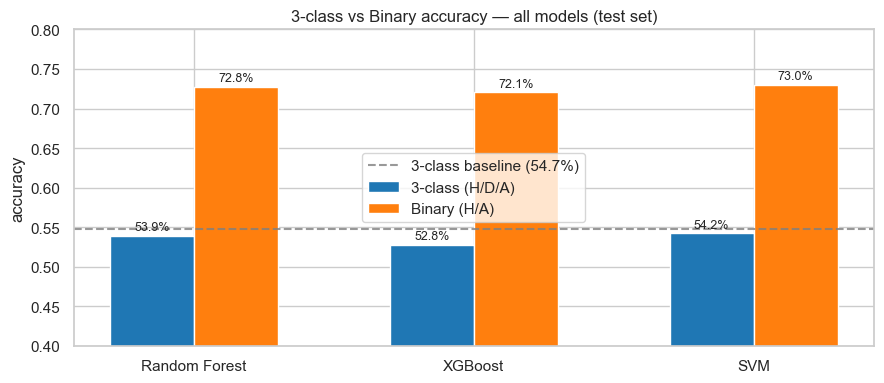

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
names = list(results_3.keys())
w = 0.3
bars1 = ax.bar(x - w/2, [results_3[n]["accuracy"] for n in names], w,
               label="3-class (H/D/A)", color="#1f77b4")
bars2 = ax.bar(x + w/2, [results_2[n]["accuracy"] for n in names], w,
               label="Binary (H/A)", color="#ff7f0e")
ax.axhline(base_test, ls="--", color="grey", alpha=.8, label=f"3-class baseline ({base_test:.1%})")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0.4, 0.80); ax.set_ylabel("accuracy")
ax.set_title("3-class vs Binary accuracy — all models (test set)")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

**What this chart tells you:**
- The gap between blue and orange bars = **how much the draw class hurts accuracy**.
- Within each colour group, the ranking of the 3 models = **true model quality** (same problem, fair comparison).
- XGBoost should lead in both (state-of-the-art for tabular data).
- SVM typically trails because it doesn't handle class imbalance or non-linear tabular features as well.


---
## 6. Feature Importance (RF & XGBoost)

SVM with RBF kernel does not produce feature importances. We plot RF and XGBoost.

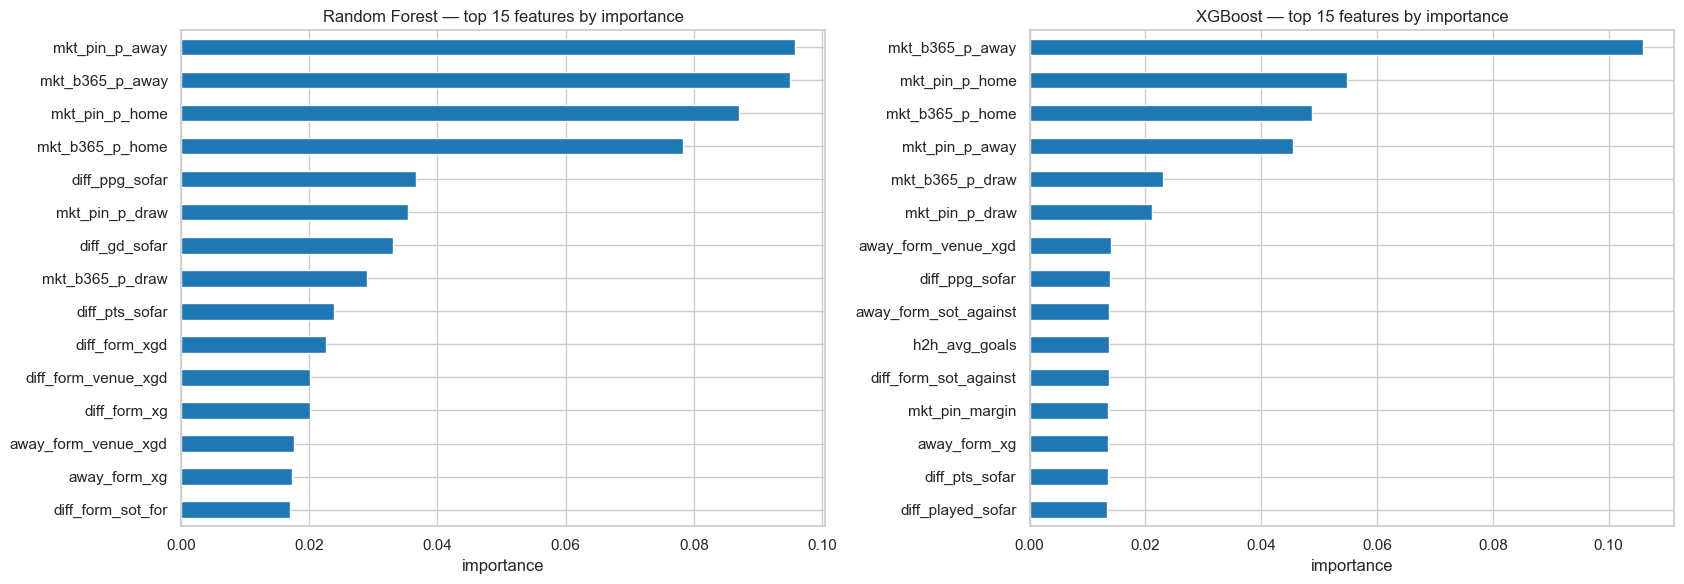

In [16]:
M.plot_importances(models_3, feat_cols, top_n=15)

**What to look for:**
- **Market features (`mkt_*`)** should rank near the top — the bookmaker encodes a huge amount of information.
- **Season-to-date difference features (`diff_ppg_sofar`, `diff_gd_sofar`)** should be strong — quality gap between the two teams.
- **Recent xG difference (`diff_form_xgd`)** — the underlying form signal.
- If both RF and XGBoost agree on the top features → those features are genuinely informative, not noise.


---
## 7. Calibration Curves

A calibration curve asks: **"When the model says 60% chance of home win, does home win actually happen 60% of the time?"**

- Perfect calibration → points sit on the diagonal.
- Curve above diagonal → model is **underconfident** (actual rate > predicted).
- Curve below diagonal → model is **overconfident** (actual rate < predicted).

Why this matters: our betting simulation in Step 5 will use model probabilities to find value bets. If the probabilities are poorly calibrated, the betting strategy will be unreliable.

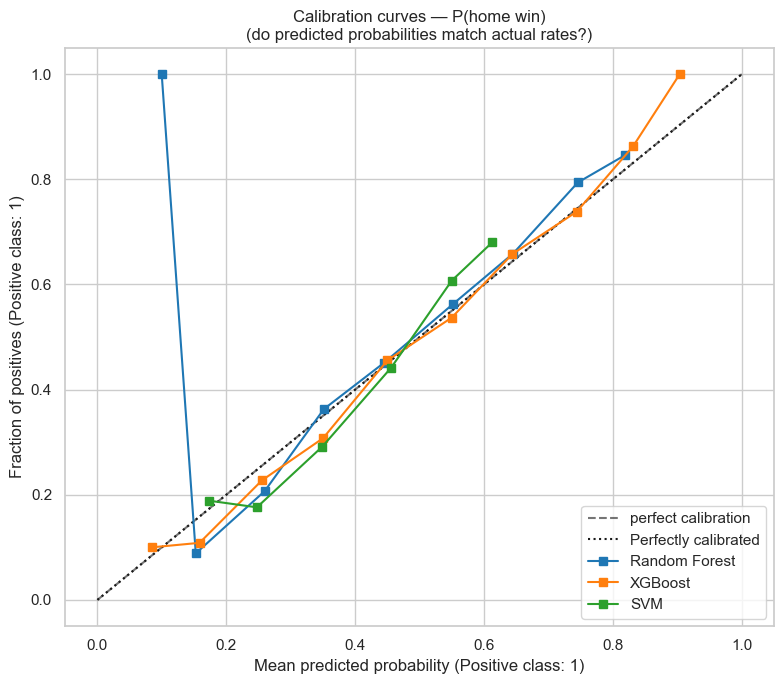

In [17]:
M.plot_calibration(models_3, X_test, y_test, le)

---
## 8. Summary

### Model Ranking (3-class, test set)

In [18]:
rank = pd.DataFrame({
    "Accuracy":     {n: r["accuracy"] for n, r in results_3.items()},
    "F1 weighted":  {n: r["report_dict"]["weighted avg"]["f1-score"] for n, r in results_3.items()},
    "Recall (D)":   {n: r["report_dict"].get("D", {}).get("recall", float("nan")) for n, r in results_3.items()},
}).round(3).sort_values("Accuracy", ascending=False)
rank.loc["Baseline"] = [round(base_test, 3), "-", "-"]
rank

,Accuracy,F1 weighted,Recall (D)
SVM,0.542,0.462,0.002
Random Forest,0.539,0.461,0.007
XGBoost,0.528,0.474,0.063
Baseline,0.547,-,-


### Key Discussion Points (for the report)

1. **Does any model beat the bookmaker baseline?**
   — If XGBoost beats 54%, it is learning real signal. If SVM doesn't, it is not competitive.

2. **The Draw problem.** Recall column for "D" is the most important single number: how often do we correctly identify a draw? It will be very low. This is the core difficulty of football prediction.

3. **Why XGBoost wins on tabular data.** Boosted trees handle non-linear feature interactions, class imbalance (via sample weighting), and heterogeneous feature scales naturally. SVM needs careful feature scaling and kernel tuning; RF averages many weak trees but doesn't iteratively correct errors the way boosting does.

4. **La Liga vs EPL.** The EDA showed EPL is slightly MORE predictable (bookmaker 55% vs 53.1%). If our models reflect this, the finding is consistent with market efficiency. If they don't, discuss why.

5. **Binary accuracy is NOT a model improvement.** When binary accuracy is ~68% vs 3-class 55%, that is NOT because the model got better — it is because we removed the hardest 26% of matches. Always frame this as "the draw class explains X% of the difficulty."

6. **Calibration matters for the betting layer.** A well-calibrated model finds value bets reliably. An overconfident model will over-bet, inflating simulated ROI artificially.
